In [1]:
import math


class Value:
    def __init__(self, data, children=(), op=''):
        self.data = data
        self.children = set(children)
        self.op = op
        self.backward = lambda: None
        self.grad = 0

    def __repr__(self):
        return f"Value : ({self.data})"

    def __add__(self, arg):
        arg = arg if isinstance(arg, Value) else Value(arg)
        out = Value(self.data + arg.data, (self, arg), '+')

        def _backward():
            self.grad += 1 * out.grad
            arg.grad += 1 * out.grad

        out.backward = _backward
        return out

    def __mul__(self, arg):
        arg = arg if isinstance(arg, Value) else Value(arg)
        out = Value(self.data * arg.data, (self, arg), '*')

        def _backward():
            self.grad += arg.data * out.grad
            arg.grad += self.data * out.grad

        out.backward = _backward
        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __radd__(self, other):  # other + self
        return self + other

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad

        out.backward = _backward
        return out

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out.backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def sigmoid(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')

        def _backward():
            out.grad += s * (1 - s) * out.grad

        out.backward = _backward
        return out

    def calculatebackward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.children:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1

        for node in reversed(topo):
            node.backward()


In [5]:
import random



class Neuron:
    def __init__(self, inputs):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(inputs)]
        self.b = Value(random.uniform(-1, 1))

    def forward(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, inp, out):
        self.n = [Neuron(inp) for _ in range(out)]

    def forward(self, x):
        outputs = []
        for n in self.n:
            outputs.append(n.forward(x))
        return outputs

    def parameters(self):
        params = []
        for nn in self.n:
            params.extend(nn.parameters())
        return params


class MLP:
    def __init__(self, inp, non):
        sizes = [inp] + non
        self.listOfLayers = []
        for i in range(len(non)):
            self.listOfLayers.append(Layer(sizes[i], sizes[i + 1]))

    def forward(self, x):
        for l in self.listOfLayers:
            x = l.forward(x)
        return x

    def parameters(self):
        params = []
        for nn in self.listOfLayers:
            params.extend(nn.parameters())
        return params


For 174 iterations :
Predicted data : 0.925
Predicted data : 0.01
Predicted data : 0.936
Predicted data : 0.008
Actual loss : 0.009894018874298216


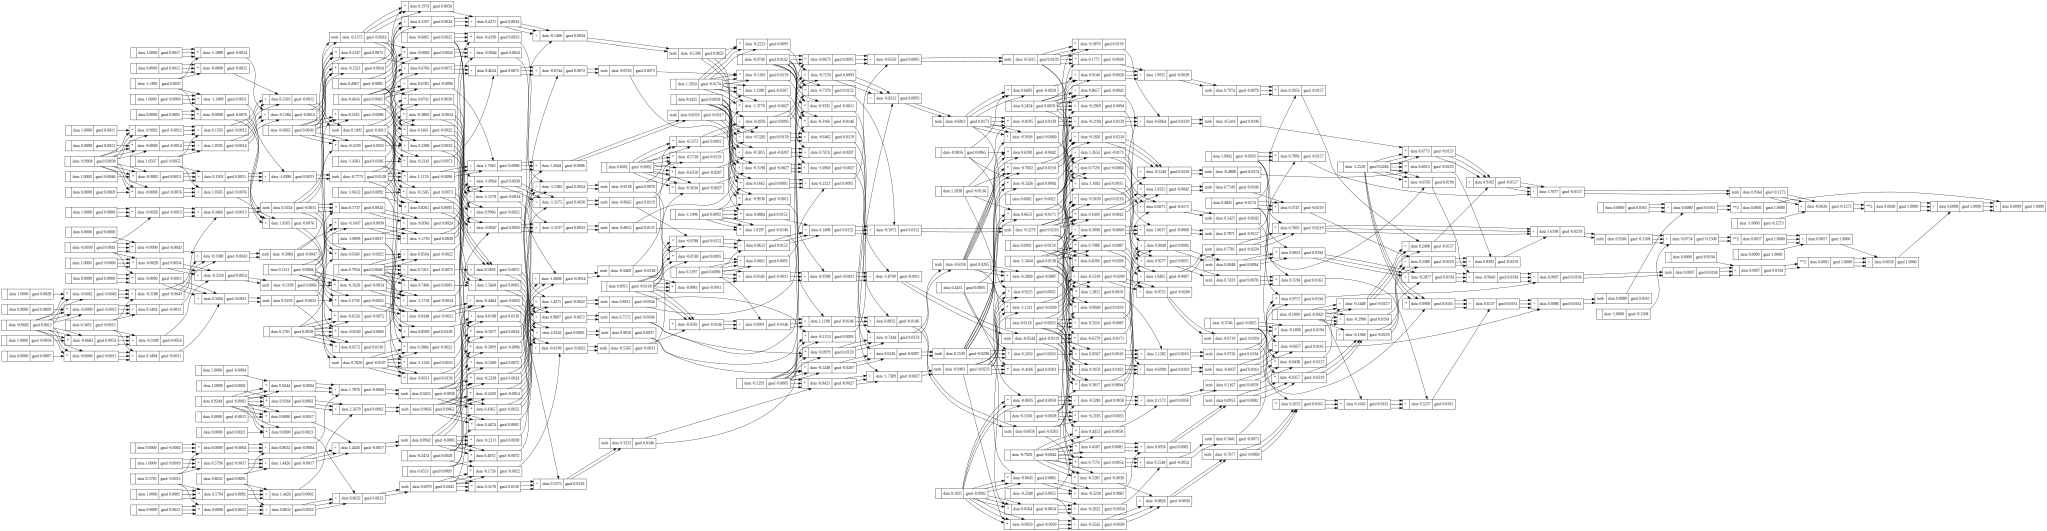

In [22]:
from IPython.display import display

class XOR:
    def __init__(self, xs, ys, model):
        self.model = model
        self.xs = xs
        self.ys = ys
        # This holds the data predicted by the model
        self.y_pred = []
        self.loss = Value(0)

    ETA = -0.05

    def _forward(self):
        self.y_pred = []
        for x in xs:
            self.y_pred.append(self.model.forward(x))

    def train(self):
        for i in range(300):

            self._forward()

            # Calculate loss
            self.loss = 0
            for y1, y2 in zip(self.y_pred, self.ys):
                self.loss = self.loss + (y1[0] - y2) ** 2

            # clear the gradient
            for p in self.model.parameters():
                p.grad = 0

            # Paramaters
            # print(f"Parameters : {len(self.model.parameters())}")

            # Back propagation
            self.loss.calculatebackward()

            # Now we update the weights, we keep the learning rate negative as we want to decrease the loss
            for p in self.model.parameters():
                p.data += (XOR.ETA * p.grad)

            # for y in self.y_pred:
                # print(f"Predicted data : {round(y[0].data, 3)} for {i} iteration(s)")
            # print(f"Actual loss : {self.loss.data}")

            if self.loss.data < 0.01:
                break
        print(f"For {i} iterations :")
        for y in self.y_pred:
                print(f"Predicted data : {round(y[0].data, 3)}")
        print(f"Actual loss : {self.loss.data}")
        display(draw_dot(self.loss))


xs = [
    [1.0, 0],
    [1.0, 1.0],
    [0, 1.0],
    [0, 0]
]

ys = [1, 0, 1, 0]

# Initialize the model
model = MLP(2, [3, 3, 2, 4, 1])

xor = XOR(xs, ys, model)
xor.train()

In [20]:
from graphviz import Digraph

def draw_dot(root, format='svg', rankdir='LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.op, n.data, n.grad), shape='record')
        if n.op:
            dot.edge(str(id(n.children.copy().pop())), str(id(n)))
            if len(n.children) == 2:
                dot.edge(str(id(n.children.copy().pop())), str(id(n)))

    # Iterate through edges again to ensure all edges are added correctly, especially for binary ops
    added_edges = set()
    for n1, n2 in edges:
        edge_tuple = (str(id(n1)), str(id(n2)))
        if edge_tuple not in added_edges:
            dot.edge(str(id(n1)), str(id(n2)))
            added_edges.add(edge_tuple)

    return dot
